# Visualizaciones Mejoradas
## BrainTumor Detector

In [5]:
import sys, os, numpy as np, matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))
from src.utils.config import TRAINING_DIR, TESTING_DIR, IMG_SIZE, MODELS_DIR, CLASSES
from src.data.loader import load_image_paths, load_and_preprocess_image
from src.data.preprocessing import encode_labels
from src.evaluation.metrics import evaluate_model
print("Cargando...")
test_paths, test_labels = load_image_paths(TESTING_DIR)
X_test, y_test = [], []
for p, l in zip(test_paths, test_labels):
    img = load_and_preprocess_image(p, IMG_SIZE)
    if img is not None:
        X_test.append(img)
        y_test.append(l)
X_test = np.array(X_test)
y_test = encode_labels(np.array(y_test))
X_test_cnn = X_test[:, :, :, :1] if X_test.shape[-1] == 3 else X_test
print(f"Testing: {X_test.shape}")

Cargando...
Testing: (1600, 128, 128, 3)


In [6]:
import tensorflow as tf
def load_keras_model(path):
    if os.path.isdir(path):
        tmp = path + "_tmp"; os.rename(path, tmp)
        try: model = tf.keras.models.load_model(tmp)
        except Exception as e: os.rename(tmp, path); raise e
        os.rename(tmp, path); return model
    return tf.keras.models.load_model(path)
modelo = load_keras_model(os.path.join(MODELS_DIR, "cnn_custom.keras"))
print("Modelo cargado")

Modelo cargado


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
y_pred = np.argmax(modelo.predict(X_test_cnn, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)
print(pd.DataFrame(report).round(4))

             glioma  meningioma   notumor  pituitary  accuracy  macro avg  \
precision    0.9828      0.6825    0.7153     0.9077    0.7925     0.8221   
recall       0.5725      0.7200    0.9925     0.8850    0.7925     0.7925   
f1-score     0.7235      0.7007    0.8314     0.8962    0.7925     0.7880   
support    400.0000    400.0000  400.0000   400.0000    0.7925  1600.0000   

           weighted avg  
precision        0.8221  
recall           0.7925  
f1-score         0.7880  
support       1600.0000  


### Grafico 1: Matriz de Confusion con Porcentajes

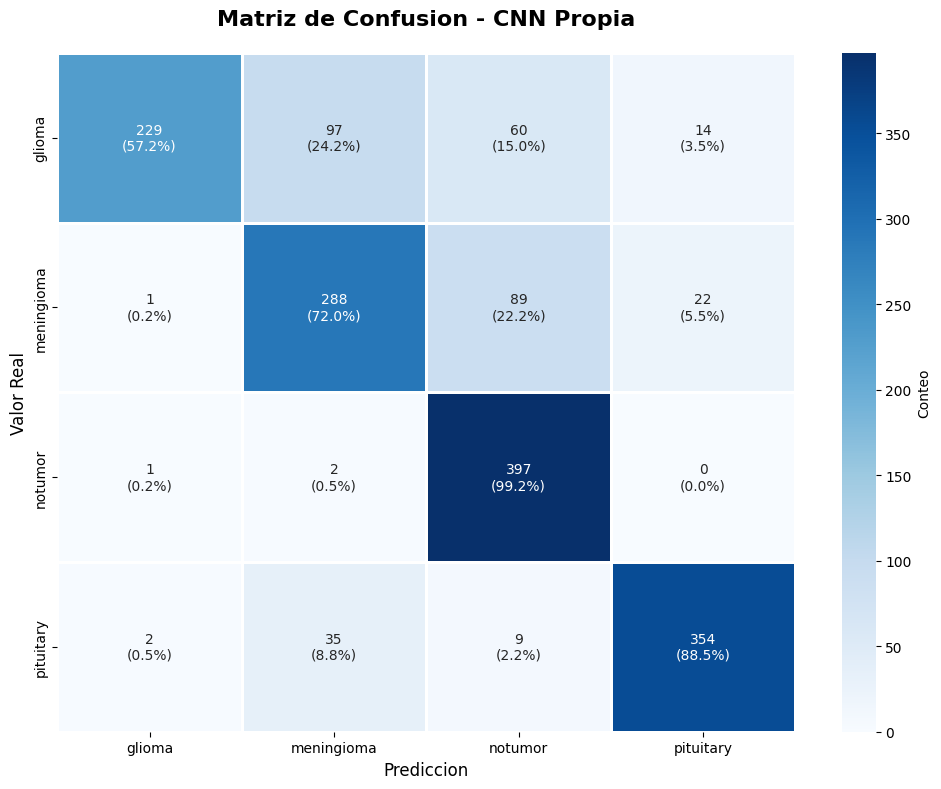

In [8]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10, 8))
cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
annot = np.array([["%d\n(%.1f%%)" % (v, p) for v, p in zip(row, p_row)] for row, p_row in zip(cm, cm_pct)])
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, linewidths=1, linecolor="white", cbar_kws={"label": "Conteo"})
ax.set_title("Matriz de Confusion - CNN Propia", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Prediccion", fontsize=12); ax.set_ylabel("Valor Real", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/mejorada_cnn_confusion_pct.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafico 2: Radar Chart Comparativo

50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 691ms/step


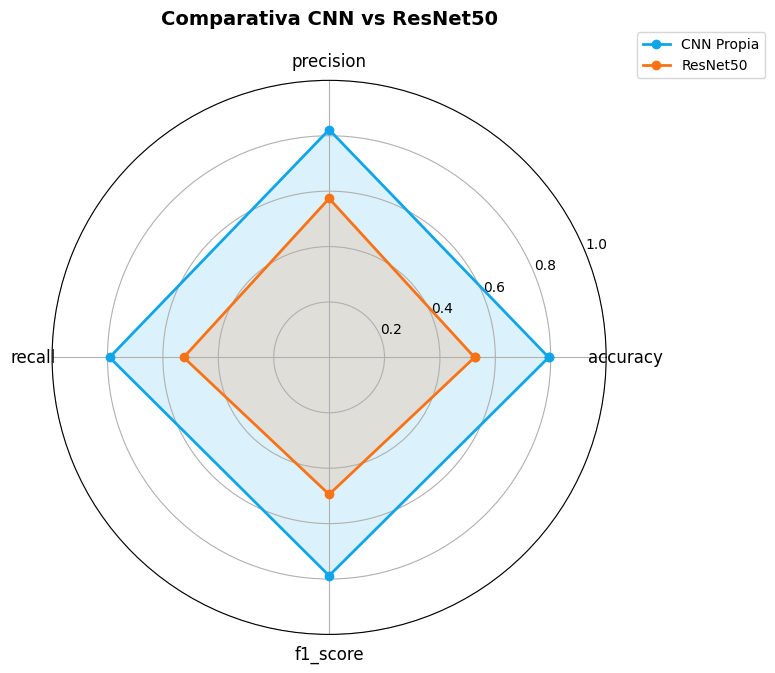

In [9]:
cnn_global, cnn_per_class, _ = evaluate_model(modelo, X_test_cnn, y_test)
try:
    resnet = load_keras_model(os.path.join(MODELS_DIR, "resnet50_finetuned.keras"))
    resnet_global, _, _ = evaluate_model(resnet, X_test, y_test)
except:
    resnet_global = {"accuracy": 0, "precision": 0, "recall": 0, "f1_score": 0}
mn = ["accuracy", "precision", "recall", "f1_score"]
cnn_vals = [cnn_global[m] for m in mn]
resnet_vals = [resnet_global[m] for m in mn]
angles = np.linspace(0, 2 * np.pi, len(mn), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(angles, cnn_vals + cnn_vals[:1], "o-", linewidth=2, label="CNN Propia", color="#0ea5e9")
ax.fill(angles, cnn_vals + cnn_vals[:1], alpha=0.15, color="#0ea5e9")
ax.plot(angles, resnet_vals + resnet_vals[:1], "o-", linewidth=2, label="ResNet50", color="#f97316")
ax.fill(angles, resnet_vals + resnet_vals[:1], alpha=0.15, color="#f97316")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(mn, fontsize=12); ax.set_ylim(0, 1)
ax.set_title("Comparativa CNN vs ResNet50", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig("../docs/mejorada_radar_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafico 3: Barras Comparativas

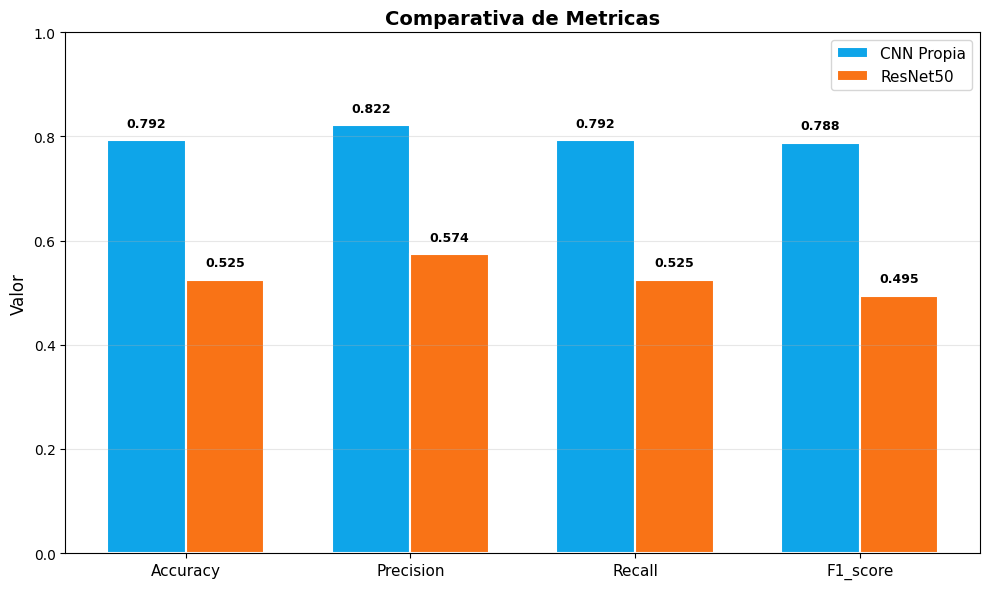

In [10]:
x = np.arange(len(mn)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, cnn_vals, width, label="CNN Propia", color="#0ea5e9", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, resnet_vals, width, label="ResNet50", color="#f97316", edgecolor="white", linewidth=1.5)
ax.set_xticks(x); ax.set_xticklabels([m.capitalize() for m in mn], fontsize=11)
ax.set_ylabel("Valor", fontsize=12); ax.set_title("Comparativa de Metricas", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, cnn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, "%.3f" % val, ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(bars2, resnet_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, "%.3f" % val, ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/mejorada_comparativa_barras.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafico 4: Metricas por Clase

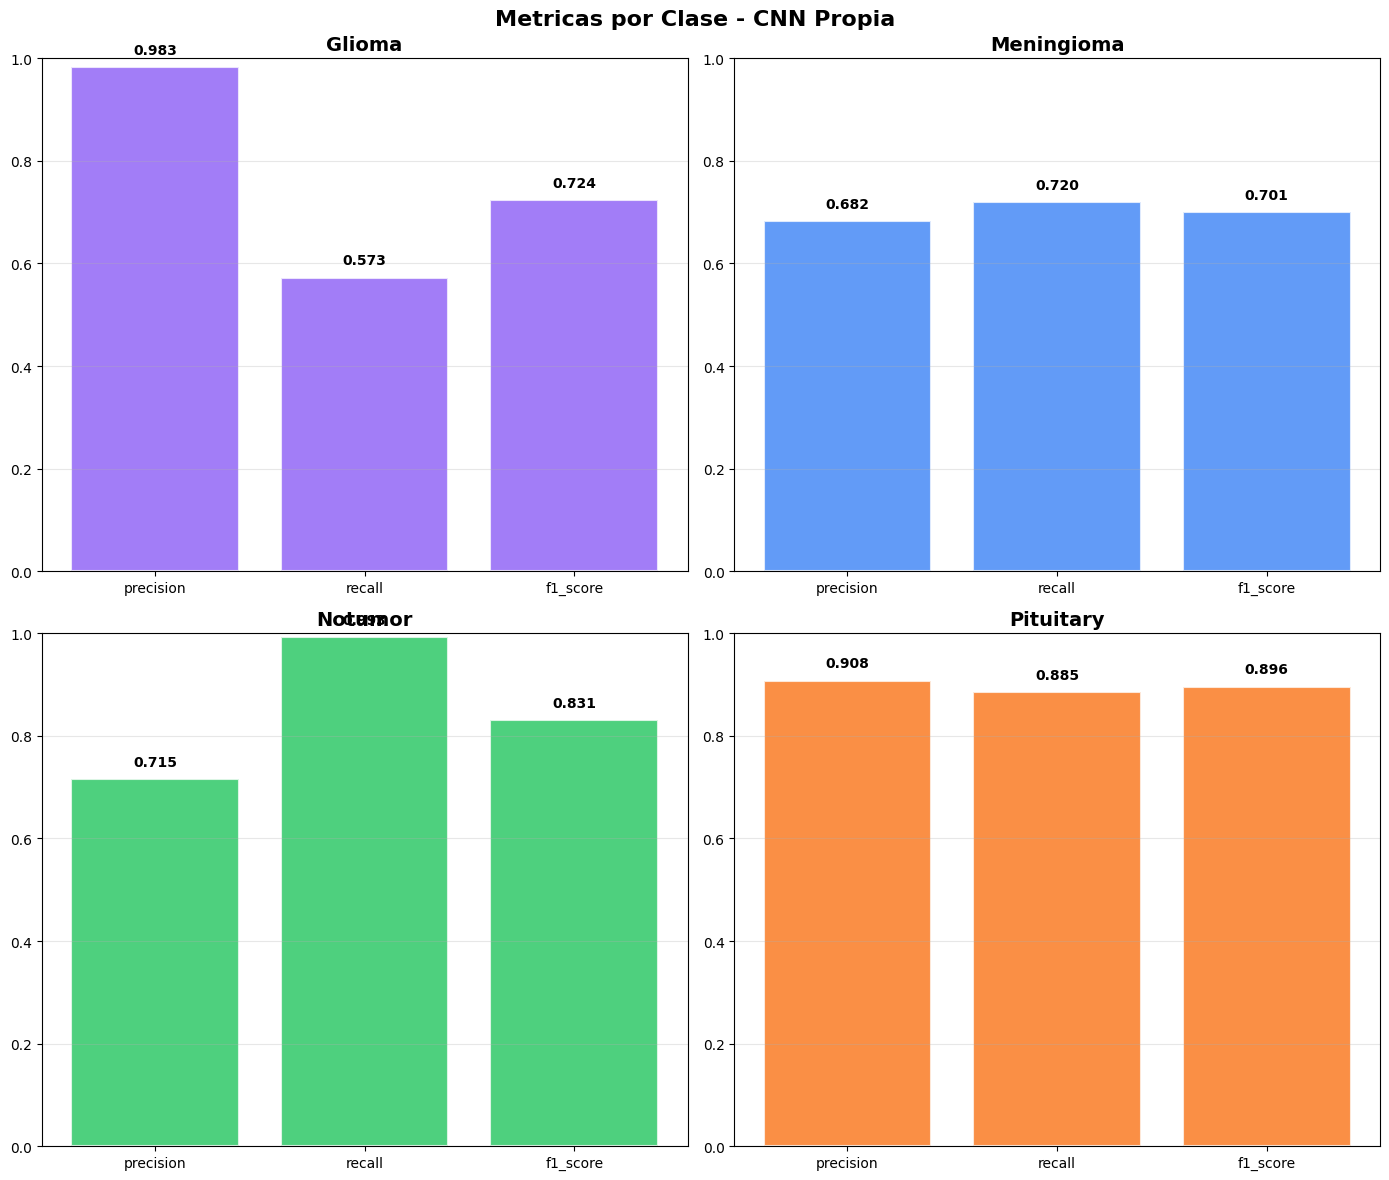

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cc = ["#8b5cf6", "#3b82f6", "#22c55e", "#f97316"]
pm = ["precision", "recall", "f1_score"]
for idx, (cn, cm_) in enumerate(cnn_per_class.items()):
    ax = axes[idx//2, idx%2]
    vals = [cm_[m] for m in pm]
    bars = ax.bar(pm, vals, color=cc[idx], alpha=0.8, edgecolor="white", linewidth=1.5)
    ax.set_title(cn.capitalize(), fontsize=14, fontweight="bold"); ax.set_ylim(0, 1); ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, "%.3f" % val, ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.suptitle("Metricas por Clase - CNN Propia", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/mejorada_metrics_clase.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafico 5: Distribucion de Clases

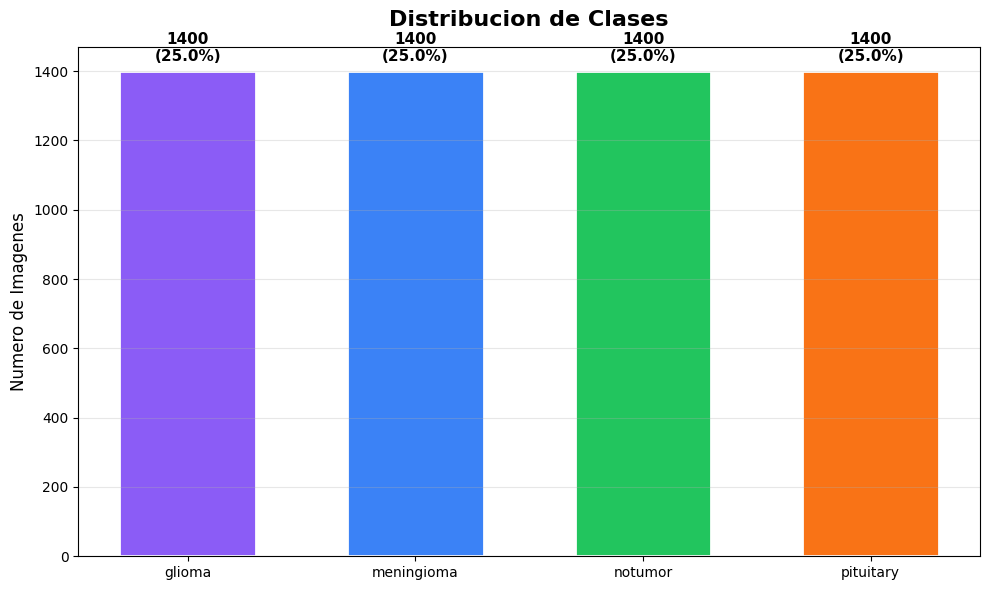

In [12]:
from src.data.loader import count_images_per_class
counts = count_images_per_class(TRAINING_DIR)
total = sum(counts.values())
fig, ax = plt.subplots(figsize=(10, 6))
cl = list(counts.keys()); vl = [counts[c] for c in cl]
bars = ax.bar(cl, vl, color=cc, edgecolor="white", linewidth=2, width=0.6)
ax.set_title("Distribucion de Clases", fontsize=16, fontweight="bold", pad=15)
ax.set_ylabel("Numero de Imagenes", fontsize=12); ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, vl):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, "%d\n(%.1f%%)" % (val, pct), ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("../docs/mejorada_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()

### Grafico 6: Curvas de Entrenamiento

In [13]:
import json
try:
    with open("../models/training_history.json", "r") as f:
        hist = json.load(f)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(hist["loss"], label="Train", color="#0ea5e9", linewidth=2)
    axes[0].plot(hist["val_loss"], label="Val", color="#f97316", linewidth=2)
    axes[0].set_title("Loss", fontsize=14, fontweight="bold"); axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist["accuracy"], label="Train", color="#0ea5e9", linewidth=2)
    axes[1].plot(hist["val_accuracy"], label="Val", color="#f97316", linewidth=2)
    axes[1].set_title("Accuracy", fontsize=14, fontweight="bold"); axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("../docs/mejorada_curvas_profesionales.png", dpi=150, bbox_inches="tight")
    plt.show()
except: print("training_history.json no encontrado")

training_history.json no encontrado


## Resumen

| Archivo | Descripcion |
|---------|-------------|
| docs/mejorada_cnn_confusion_pct.png | Matriz con %% |
| docs/mejorada_radar_metrics.png | Radar comparativo |
| docs/mejorada_comparativa_barras.png | Barras comparativas |
| docs/mejorada_metrics_clase.png | Metricas por clase |
| docs/mejorada_distribucion.png | Distribucion de clases |
| docs/mejorada_curvas_profesionales.png | Curvas entrenamiento |